In [8]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

data = load_breast_cancer()

X, y = data.data, data.target

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_idx, test_idx = next(skf.split(X, y))
X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

mlp = MLPClassifier()
mlp.fit(X_train, y_train)
y_predict = mlp.predict(X_test)

print(f"Accuracy Score (MLPClassifier): {accuracy_score(y_test, y_predict):.2f}")
print("========================================")
print(classification_report(y_test, y_predict))

Accuracy Score (MLPClassifier): 0.96
              precision    recall  f1-score   support

           0       0.93      0.98      0.95        43
           1       0.99      0.96      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [5]:
params_grid = {
    'alpha' : [0.0001, 0.01, 0.1],
    'learning_rate_init' : [0.0001, 0.001, 0.01, 0.1],
    'max_iter' : [200, 500, 800],
    'hidden_layer_sizes' : [50, 100, 200]
}   

model = MLPClassifier()
clf = RandomizedSearchCV(
    estimator=model,
    param_distributions=params_grid,
    cv=5)
clf.fit(X_train, y_train)
y_predict = clf.predict(X_test)
best = clf.best_estimator_
print(f"Best Parameters: {clf.best_params_}")
print(f"Accuracy Score: {accuracy_score(y_test, y_predict):.2f}")
print(classification_report(y_test, y_predict))

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptro

Best Parameters: {'max_iter': 800, 'learning_rate_init': 0.001, 'hidden_layer_sizes': 200, 'alpha': 0.0001}
Accuracy Score: 0.97
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        43
           1       1.00      0.96      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.98      0.97       114
weighted avg       0.98      0.97      0.97       114



## Confusion Matrix

Text(50.722222222222214, 0.5, 'Actual')

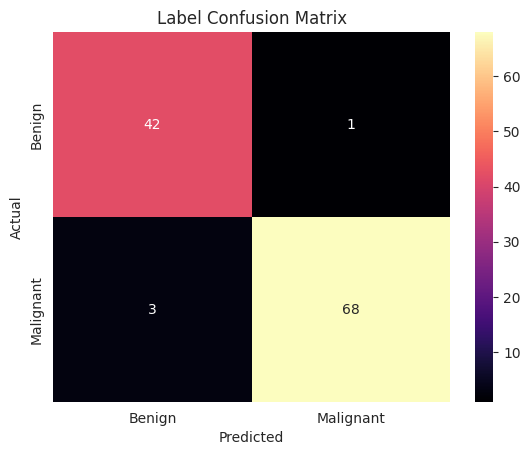

In [14]:
cm = confusion_matrix(y_test, y_predict)
sns.set_style('whitegrid')
labels = ['Benign', 'Malignant']
sns.heatmap(
    cm, annot=True, xticklabels=labels,
    yticklabels=labels, cmap='magma'
)

plt.title("Label Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')